In [1]:
%%time
%matplotlib inline

import importlib
import new_import  

importlib.reload(new_import)


from new_import import *

CPU times: user 13.3 s, sys: 3.12 s, total: 16.4 s
Wall time: 10.3 s


In [2]:
%%time
# Cấu hình Daskgateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()

client

An existing cluster was found. Connecting to: easihub.8daaa179e4964dc7b211b4302753bf26
CPU times: user 689 ms, sys: 57.7 ms, total: 747 ms
Wall time: 2min 20s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.8daaa179e4964dc7b211b4302753bf26/status,


2025-01-18 10:50:14,316 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [3]:
date_range = ('2022-09-01', '2023-10-30')
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0) 

coordinates = (longtitude_range, latitude_range)

In [4]:
# tải dữ liệu vh vv từ vệ tinh sentinel-1
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)

<xarray.Dataset> Size: 25GB
Dimensions:      (time: 35, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 280B 2022-09-06T22:46:14.500000 ... 20...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 12GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [5]:
average_vh = calculate_average(dsvh, time_pattern='1M')
progress(average_vh)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [6]:
average_vv = calculate_average(dsvv, time_pattern='1M')
progress(average_vv)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [7]:
%%time
average_vh.compute()
average_vv.compute()

CPU times: user 9.29 s, sys: 7.41 s, total: 16.7 s
Wall time: 5min 25s


<xarray.DataArray 'vv' (time: 14, y: 8874, x: 9902)> Size: 5GB
array([[[0.06906006, 0.07957305, 0.09409785, ..., 0.23094253,
         0.23027407, 0.23319586],
        [0.06906006, 0.07957305, 0.09409785, ..., 0.23425393,
         0.23664413, 0.2474947 ],
        [0.07378212, 0.08650854, 0.10212713, ..., 0.24990971,
         0.23486657, 0.24579485],
        ...,
        [0.07391845, 0.07370436, 0.07163539, ..., 0.04897952,
         0.04920945, 0.04933887],
        [0.07343939, 0.07252609, 0.0702525 , ..., 0.04814997,
         0.0479173 , 0.04799423],
        [0.07355063, 0.07199537, 0.06989169, ..., 0.04814997,
         0.0479173 , 0.04799423]],

       [[0.00899241, 0.00861329, 0.00829276, ..., 0.23408818,
         0.2404511 , 0.24306983],
        [0.00899241, 0.00861329, 0.00829276, ..., 0.25091022,
         0.25812387, 0.2747655 ],
        [0.00900787, 0.00860327, 0.00830202, ..., 0.2770343 ,
         0.27153593, 0.29995093],
...
        [0.11153916, 0.13004702, 0.12090257, ..., 0.05369304,
         0.05208092, 0.04936117],
        [0.10719641, 0.11629926, 0.11002686, ..., 0.05484349,
         0.05366876, 0.05158882],
        [0.10319728, 0.10290676, 0.09967952, ..., 0.05484349,
         0.05366876, 0.05158882]],

       [[0.00969094, 0.01002615, 0.01025252, ..., 0.2466253 ,
         0.25675553, 0.2808404 ],
        [0.00969094, 0.01002615, 0.01025252, ..., 0.27609208,
         0.28855708, 0.33027148],
        [0.00952399, 0.00974397, 0.01000167, ..., 0.31602195,
         0.33647415, 0.37436265],
        ...,
        [0.07525177, 0.07550529, 0.07569483, ..., 0.01599048,
         0.01579917, 0.01585157],
        [0.07992493, 0.07882614, 0.07751034, ..., 0.01602835,
         0.01578975, 0.01558014],
        [0.08913893, 0.08342338, 0.07963105, ..., 0.01602835,
         0.01578975, 0.01558014]]], dtype=float32)
Coordinates:
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
  * time         (time) datetime64[ns] 112B 2022-09-30 2022-10-31 ... 2023-10-31
Attributes:
    units:         intensity
    nodata:        nan
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [8]:
data_sen2 = load_data_sen2(dc, date_range, coordinates)
notebook_utils.heading(notebook_utils.xarray_object_size(data_sen2))
display(data_sen2)

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 129GB
Dimensions:      (time: 163, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 57GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 57GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 14GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [9]:
%%time
# Tiến hành loại bỏ các vị trí bị mây ảnh hưởng
result = mask_cloud(data_sen2)
progress(result)

{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

CPU times: user 989 ms, sys: 30.2 ms, total: 1.02 s
Wall time: 1.02 s


VBox()

In [10]:
# calculate NDVI
dsNDVI = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = dsNDVI["NDVI"]
display(ndvi)


<xarray.DataArray 'NDVI' (time: 163, y: 8874, x: 9902)> Size: 57GB
dask.array<truediv, shape=(163, 8874, 9902), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648

In [11]:
%%time
# calculate average NDVI
average_ndvi = calculate_average(ndvi,time_pattern="1M")
progress(average_ndvi)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


CPU times: user 519 ms, sys: 0 ns, total: 519 ms
Wall time: 517 ms


VBox()

2025-01-18 10:49:45,083 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fd6b10ef350>>, <Task finished name='Task-1789' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=CommClosedError('in <TLS (closed)  local=tls://10.0.74.241:51368 remote=gateway://traefik-dask-gateway.easihub:80/easihub.8daaa179e4964dc7b211b4302753bf26>: Stream is closed')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/env/lib/python3.12/

In [12]:
average_ndvi = average_ndvi.compute()

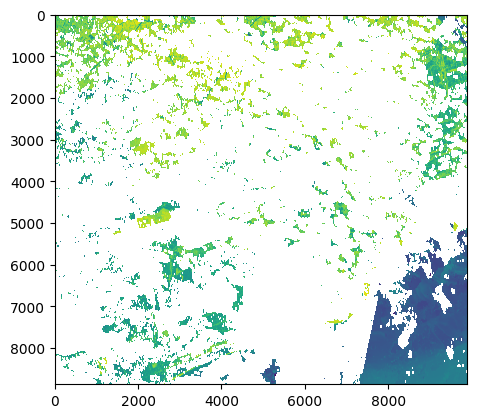

In [13]:
plt.imshow(average_ndvi.isel(time=0))

#####################################################################################

In [15]:
train_path = "input/train_points/1130/ST_1130_points.shp"  
# train_path = "train/updated_data/ThuanHoa_DKS_Kappa.shp"
ground_points = load_data_geo(train_path)
ground_points.shape

(1130, 7)

In [28]:
fill_nan_model = joblib.load('output/regressors/mean_no_negative/rf_cloud.pkl')

In [23]:

def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [24]:
data = extract_data_with_HTcode(ground_points, average_ndvi, average_vh, average_vv)

*********************************************************************************************************

In [32]:
import numpy as np

# Function to filter out NaN values for each 'ndvi' array in each HT_code
def filter_non_nan_ndvi(data):
    filtered_data = {}
    
    for ht_code, attributes in data.items():
        # Initialize lists to store filtered arrays for 'ndvi', 'vh', and 'vv'
        filtered_ndvi = []
        filtered_vh = []
        filtered_vv = []
        
        # Iterate through each set of ndvi, vh, vv arrays
        for ndvi, vh, vv in zip(attributes['ndvi'], attributes['vh'], attributes['vv']):
            # Create masks to filter out NaN values based on 'ndvi' array
            non_nan_mask = ~np.isnan(ndvi)
            
            # Filter the arrays based on the mask
            filtered_ndvi.append(ndvi[non_nan_mask])
            filtered_vh.append(vh[non_nan_mask])
            filtered_vv.append(vv[non_nan_mask])
        
        # Only add if there are non-empty filtered values
        filtered_data[ht_code] = {
            'ndvi': filtered_ndvi,
            'vh': filtered_vh,
            'vv': filtered_vv
        }
    
    return filtered_data

# Example usage
filtered_datasets = filter_non_nan_ndvi(data)



In [ ]:
# filtered_datasets

In [34]:
# cấu hình nhãn dữ liệu
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7"
}

^^^^^^^^^^^^^^^^^^^^^^^^^^^NEW VERSION OF GRPAH^^^^^^^^^^^^^^^^

In [25]:
import matplotlib.pyplot as plt

def draw(ndvi_values, predicted_values, name):
    for i, (ndvi, predicted) in enumerate(zip(ndvi_values, predicted_values)):
        plt.plot(ndvi, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
        plt.plot(predicted, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75, label='Predicted Values (x)' if i == 0 else "")
        # plt.plot(ndvi, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75)
        # plt.plot(predicted, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75)
    
    # Adding labels and title
    plt.xlabel('Months')
    plt.ylabel('NDVI values')
    plt.title(f'Comparison: Actual vs Predicted Values in {name} code over 13 months')
    # Adding grid
    plt.grid(True)
    plt.legend(loc='best')
    # Adding legend to differentiate the lines
    plt.legend()
    # Adjusting the limits of the axes
    plt.xlim(0, max(len(arr) for arr in ndvi_values))  # Adjust x-axis limits based on the longest array
    plt.ylim(-1, 1)  # Example: Setting y-axis limits
    # Display the plot
    plt.show()


In [26]:
def show_images(ht_code, indices, name):
    all_ndvi_values = []
    all_predicted_ndvi_values = []

    # Iterate over the list of vh_values and vv_values
    for index in range(indices):
        # Extract the values for the given index range
        ndvi_values = data[ht_code]['ndvi'][index]
        vh_values = data[ht_code]['vh'][index]
        vv_values = data[ht_code]['vv'][index]
        # Combine vh and vv into input data
        input_data = np.column_stack((vh_values, vv_values))
        # Predict NDVI values
        predicted_ndvi = fill_nan_model.predict(input_data)
        # Collect the values for plotting
        all_ndvi_values.append(ndvi_values)
        all_predicted_ndvi_values.append(predicted_ndvi)
    # Draw the plots for all the data
    draw(all_ndvi_values, all_predicted_ndvi_values, name)


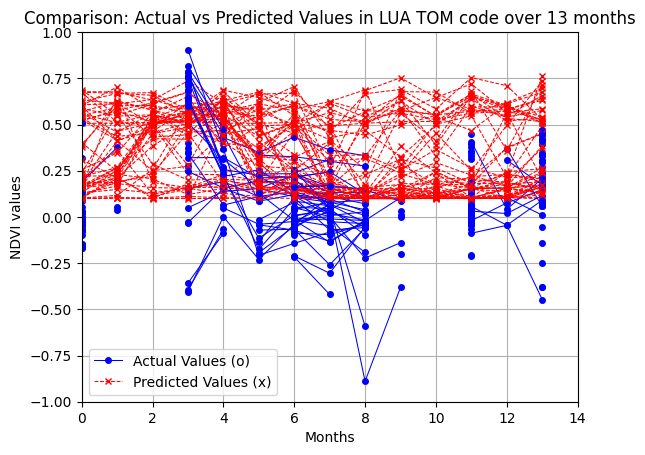

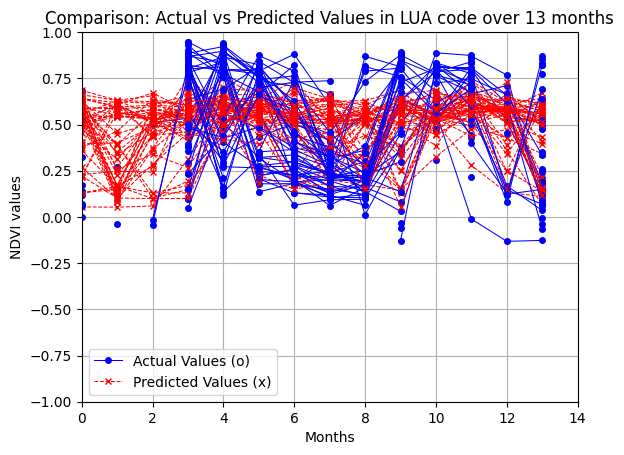

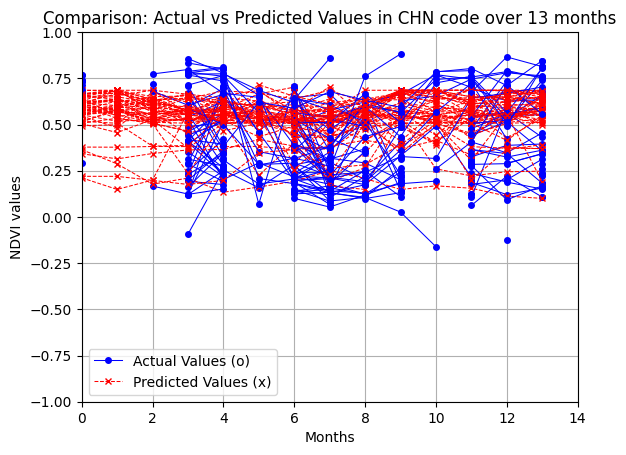

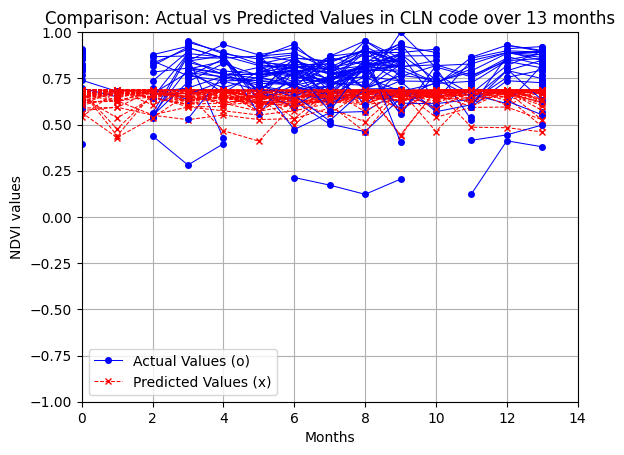

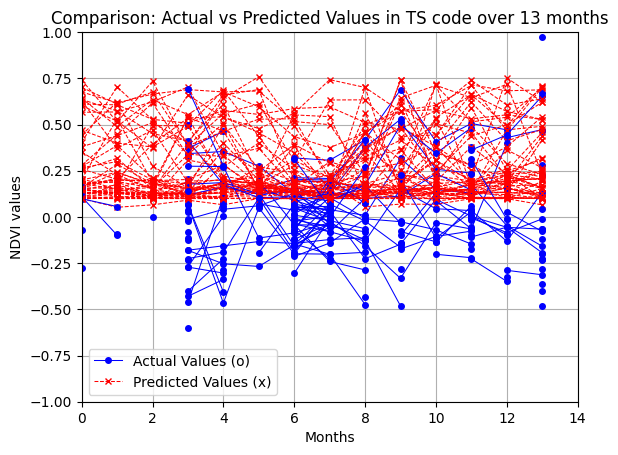

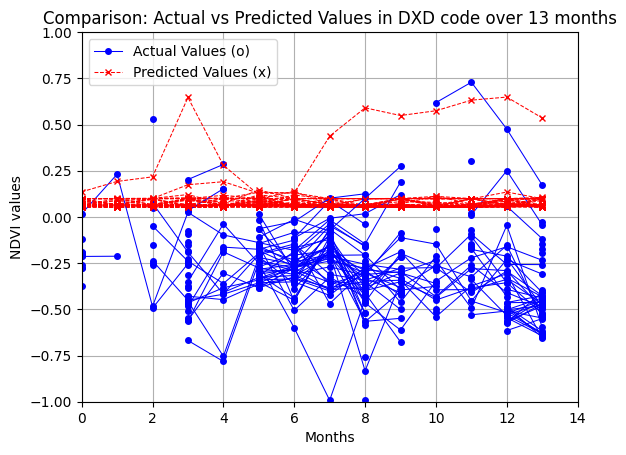

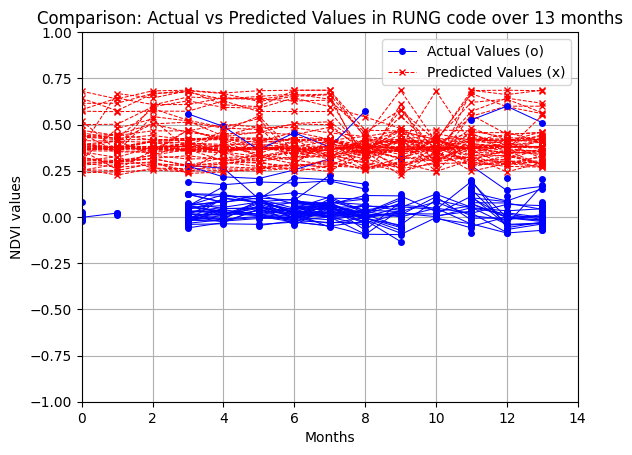

In [29]:
labels = ["LUA TOM", "LUA", "CHN", "CLN", "TS", "DXD", "RUNG"]
for i in range(0, 7):
    show_images(i, 50, labels[i])